# Dynamical clustering 


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from swot import (
    browse_swot_250,
    add_mask_inside_swot,
    build_swath_polygon,
    browse_swot_2km,
)
from diagnosis import (
    dataset_coloc_combs,
    DRIFTER,
    ALTI,
    WD,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_mean_square,
    compute_mean_square_groupby,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

_______
# Data

In [2]:
# alternative functions (more variables)

dtypes = {"drifter_id": str}


def prepared_drifters(drifter_key):
    dfr = pd.read_csv(
        DRIFTER[drifter_key], parse_dates=["datetime"], dtype=dtypes
    ).set_index("row_number")
    dfr["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(dfr.latitude * np.pi / 180)
    dfr["core"] = -dfr.f * dfr.velocity_north
    dfr["corn"] = dfr.f * dfr.velocity_east
    dfr = dfr.rename(
        columns={"acceleration_north": "accn", "acceleration_east": "acce"}
    )
    return dfr


def prepared_alti(
    alti_key,
    ggd_var=[
        "duacs_ssha_karin_2_filtered",
        "duacs_ssha_karin_2_calibrated",
        "cvl_mean_dynamic_topography_cnes_cls_22",
        "cvl_ocean_tide_fes_2022",
    ],
):
    dfs = pd.read_csv(ALTI[alti_key]).set_index("row_number")
    dfs["f"] = 2 * 2 * np.pi / 86164.1 * np.sin(dfs.latitude * np.pi / 180)
    dfs["ggde_fromduacsv"] = dfs.f * dfs.duacs_speed_meridional_abs
    dfs["ggdn_fromduacsv"] = -dfs.f * dfs.duacs_speed_zonal_abs
    dfs = dfs[
        ["ggde_" + v for v in ggd_var]
        + ["ggdn_" + v for v in ggd_var]
        + ["ggde_fromduacsv", "ggdn_fromduacsv"]
    ]
    dfs["ggde_etaf"] = (
        dfs.ggde_duacs_ssha_karin_2_filtered
        + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
        + dfs.ggde_cvl_ocean_tide_fes_2022
    )
    dfs["ggdn_etaf"] = (
        dfs.ggdn_duacs_ssha_karin_2_filtered
        + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
        + dfs.ggdn_cvl_ocean_tide_fes_2022
    )
    dfs["ggde_adtf"] = (
        dfs.ggde_duacs_ssha_karin_2_filtered
        + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    )
    dfs["ggdn_adtf"] = (
        dfs.ggdn_duacs_ssha_karin_2_filtered
        + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    )
    dfs["ggde_etac"] = (
        dfs.ggde_duacs_ssha_karin_2_calibrated
        + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
        + dfs.ggde_cvl_ocean_tide_fes_2022
    )
    dfs["ggdn_etac"] = (
        dfs.ggdn_duacs_ssha_karin_2_calibrated
        + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
        + dfs.ggdn_cvl_ocean_tide_fes_2022
    )
    dfs["ggde_adtc"] = (
        dfs.ggde_duacs_ssha_karin_2_calibrated
        + dfs.ggde_cvl_mean_dynamic_topography_cnes_cls_22
    )
    dfs["ggdn_adtc"] = (
        dfs.ggdn_duacs_ssha_karin_2_calibrated
        + dfs.ggdn_cvl_mean_dynamic_topography_cnes_cls_22
    )
    return dfs  # .rename(columns ={v : v+'_' +alti_key for v in dfs})


def prepared_wd(wd_key):
    dfw = pd.read_csv(WD[wd_key]).set_index("row_number")
    # dfw = dfw[[v for v in dfw if ('wde' in v or 'wdn' in v)]]
    return dfw.drop(
        columns=["longitude", "latitude"]
    )  # .rename(columns ={v : v+'_' +wd_key for v in dfw})

In [3]:
comb_list = [
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    ),
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="15",
    ),
]

DS = dataset_coloc_combs(comb_list, nearest=False)
DS = DS.where(DS.time_to_swot / pd.Timedelta("1h") < 12).dropna("row_number")
DSS = DS.where(DS.depth == 0, drop=True).isel(id_comb=[0])
DSD = DS.where(DS.depth == 15, drop=True).isel(id_comb=[1])

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5
Identified SWOT and drifter outliers have been removed


In [14]:
dfr = prepared_drifters("nofilter")
dfr["inertial_U"] = np.sqrt(
    dfr.inertial_velocity_east**2 + dfr.inertial_velocity_north**2
)
dfr["inertial_A"] = np.sqrt(
    dfr.inertial_acceleration_east**2 + dfr.inertial_acceleration_north**2
)
dfr["other_U"] = np.sqrt(dfr.other_velocity_east**2 + dfr.other_velocity_north**2)
dfr["diurnal_U"] = np.sqrt(
    dfr.diurnal_velocity_east**2 + dfr.diurnal_velocity_north**2
)
dfr["semidiurnal_U"] = np.sqrt(
    dfr.semidiurnal_velocity_east**2 + dfr.semidiurnal_velocity_north**2
)

In [15]:
dfs = DSS.to_dataframe().reset_index().set_index("row_number")
dfs

,id_comb,sume,acce,exce_acc,core,exce_cor,ggde,exce_ggd,wde,exce_wd,...,datetime,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,phi
row_number,,,,,,,,,,,,,,,,,,,,,
143,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000011,-0.000008,-0.000003,0.000012,-0.000023,-4.585485e-07,-0.000010,-0.000015,3.901336e-06,...,2023-04-01 11:50:00,5.537802,42.311468,3,0 days 11:52:32.696536,478,0-4351296,CARTHE,0,1.818422
144,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000011,-0.000009,-0.000002,0.000012,-0.000023,-6.607189e-07,-0.000010,-0.000014,2.858267e-06,...,2023-04-01 12:00:00,5.538871,42.310796,3,0 days 11:42:32.696536,478,0-4351296,CARTHE,0,1.818434
145,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000012,-0.000009,-0.000003,0.000012,-0.000024,-8.581123e-07,-0.000011,-0.000014,1.885749e-06,...,2023-04-01 12:10:00,5.539902,42.310135,3,0 days 11:32:32.696536,478,0-4351296,CARTHE,0,1.818446
146,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000013,-0.000010,-0.000003,0.000012,-0.000024,-1.232983e-06,-0.000011,-0.000014,8.164491e-07,...,2023-04-01 12:20:00,5.540894,42.309485,3,0 days 11:22:32.696536,478,0-4351296,CARTHE,0,1.818479
147,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000013,-0.000010,-0.000003,0.000011,-0.000025,-1.402873e-06,-0.000012,-0.000013,4.537818e-08,...,2023-04-01 12:30:00,5.541843,42.308849,3,0 days 11:12:32.696536,478,0-4351296,CARTHE,0,1.818488
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404014,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000015,-0.000010,-0.000005,0.000015,-0.000030,-1.860575e-05,0.000004,-0.000002,-1.264564e-05,...,2023-07-10 06:10:00,2.018496,41.064212,16,0 days 11:13:38.131544384,577,295,HEREON,0,-1.801991
404015,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000015,-0.000010,-0.000006,0.000016,-0.000031,-1.907014e-05,0.000004,-0.000002,-1.312329e-05,...,2023-07-10 06:20:00,2.016917,41.063333,16,0 days 11:23:38.131544384,577,295,HEREON,0,-1.802017
404016,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000016,-0.000009,-0.000006,0.000016,-0.000031,-1.934048e-05,0.000004,-0.000002,-1.331408e-05,...,2023-07-10 06:30:00,2.015297,41.062453,16,0 days 11:33:38.131544384,577,295,HEREON,0,-1.802033


In [19]:
def plot_bins_diag(dfs, dfr, key_bins):
    # bins
    df = pd.concat([dfs, dfr[key_bins]], axis=1).dropna()
    quantile = np.array(
        [0] + [df[key_bins].quantile(i) for i in np.linspace(1e-3, 1 - 1e-3, 30)]
    )  # 15 = 10 000 par cut
    df[key_bins + "_cut"] = pd.cut(
        df[key_bins], quantile, labels=(quantile[1:] + quantile[:-1]) / 2
    )
    ds = compute_mean_square_groupby(df, groupby=key_bins + "_cut")

    # bootstrap errors
    DF = []
    for v in vars_errors:
        DF.append(
            df.reset_index()[vars_errors + ["latbin", "lonbin"]]
            .groupby(["latbin", "lonbin"])[v]
            .apply(compute_bootstrap_error)
            .compute()
        )
    booterrors = pd.concat(DF, axis=1)
    booterrors = booterrors.rename(columns={v: "be__" + v for v in booterrors.columns})

    # plot pair's contributions
    Xn = [k for k in ds.keys() if "Xn" in k]
    Xe = [k for k in ds.keys() if "Xe" in k]
    xstyle = {
        l.replace("Xn_", ""): dict(
            color=c0[l.split("_")[1]],
            marker="x",
            markeredgecolor=c0[l.split("_")[2]],
            markersize=3,
        )
        for l in Xn
    }

    fig, axs = plt.subplots(1, 3, figsize=(15, 6))
    axs = axs.flatten()
    for xn in Xn:
        ds[xn].plot(ax=axs[1], label=xn, **xstyle[xn.replace("Xn_", "")])
    for xe in Xe:
        ds[xe].plot(ax=axs[0], label=xe, **xstyle[xe.replace("Xe_", "")])
    i = 0
    for xn in Xn:
        (ds[xn] + ds[Xe[i]]).plot(ax=axs[2], label=xn, **xstyle[xn.replace("Xn_", "")])
        i += 1

    fig.tight_layout()
    for ax in axs:
        ax.grid()
        ax.set_ylabel(r"[$\gamma^2$]")
    axs[0].legend()

    axs[0].set_title("Zonal")
    axs[1].set_title("Meridional")
    axs[2].set_title("Total")

    axs[2].set_ylim(-5, 40)

    # plot residual vs balanced part contribution
    Bn = [k for k in ds.keys() if "Bn" in k]
    Be = [k for k in ds.keys() if "Be" in k]

    fig, axs = plt.subplots(
        3,
        4,
        figsize=(15, 12),
        sharex=True,
    )
    axs = axs.flatten()
    i = 0
    for be in Be:
        ax = axs[i]
        ds[be].plot(ax=ax, label=be, color=c0[be.replace("Be_", "")])
        ds[be.replace("Be_", "Ee_")].plot(
            ax=ax, color=c0[be.replace("Be_", "")], ls="--"
        )
        i += 1
        ax.set_title("Zonal balanced contribution " + be.replace("Be_", ""))

    for bn in Bn:
        ax = axs[i]
        ds[bn].plot(ax=ax, label=bn, color=c0[bn.replace("Bn_", "")])
        ds[bn.replace("Bn_", "En_")].plot(
            ax=ax, color=c0[bn.replace("Bn_", "")], ls="--"
        )
        i += 1
        ax.set_title("Meridional balanced contribution " + bn.replace("Bn_", ""))

    for bn in Bn:
        ax = axs[i]
        (ds[bn] + ds[Be[i - 8]]).plot(ax=ax, label=bn, color=c0[bn.replace("Bn_", "")])
        (ds[bn.replace("Bn_", "En_")] + ds[Be[i - 8].replace("Be_", "Ee_")]).plot(
            ax=ax, color=c0[bn.replace("Bn_", "")], ls="--"
        )
        i += 1
        ax.set_title("Total balanced contribution " + bn.replace("Bn_", ""))

    fig.tight_layout()
    for ax in axs:
        ax.grid()
        ax.set_ylabel(r"[$\gamma^2$]")

    fig.tight_layout()

______
# Surface Constrained with inertial velocity + constant number of coloc in bins


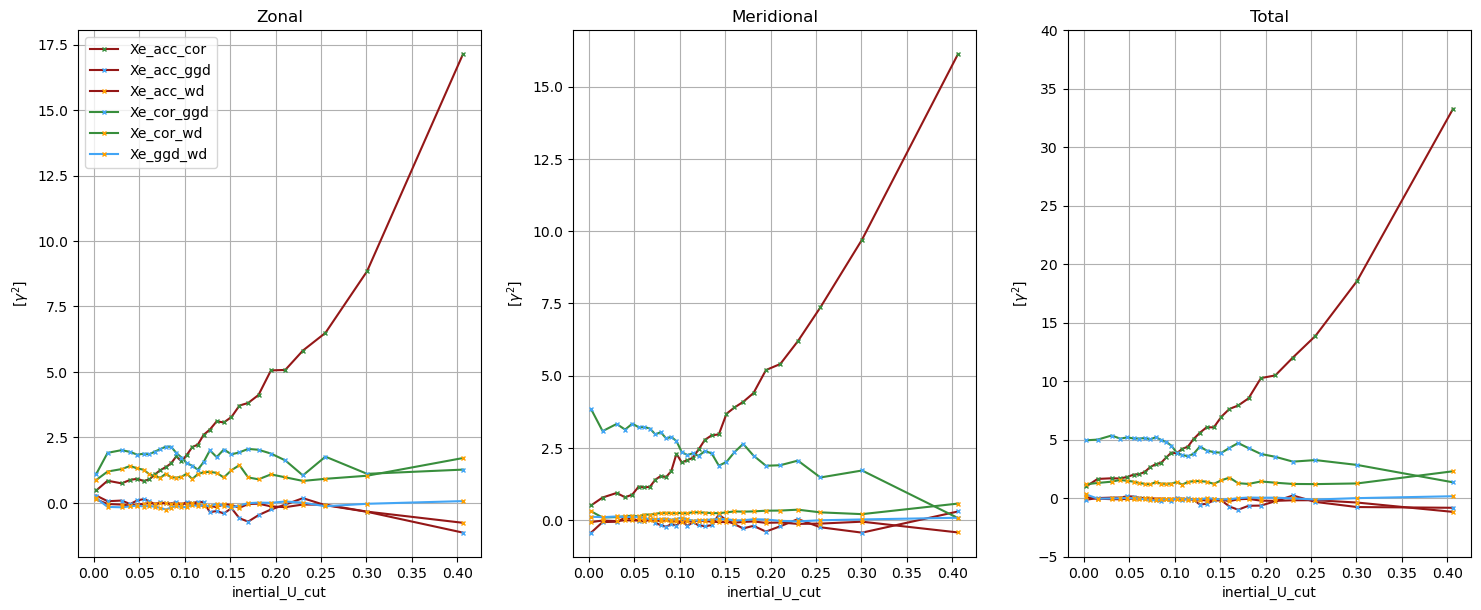

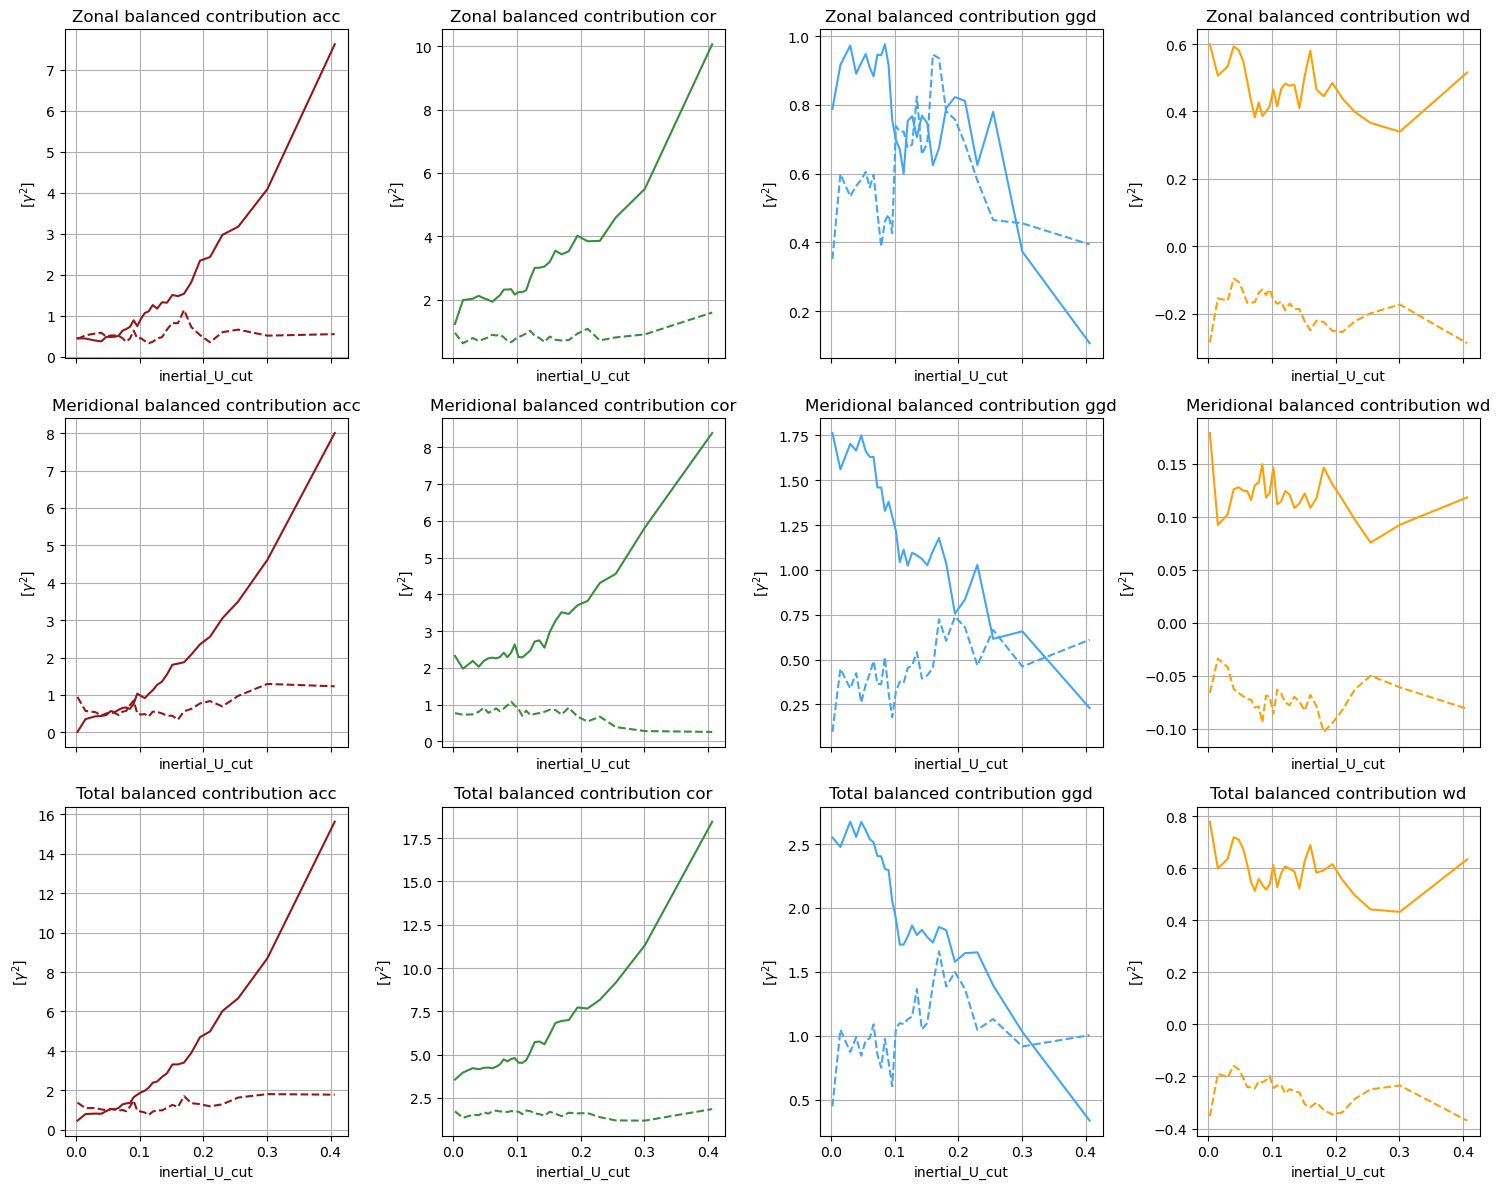

In [20]:
plot_bins_diag(dfs, dfr, "inertial_U")

__________
# Surface constrained with inertial acceleration + constants number of coloc per bins

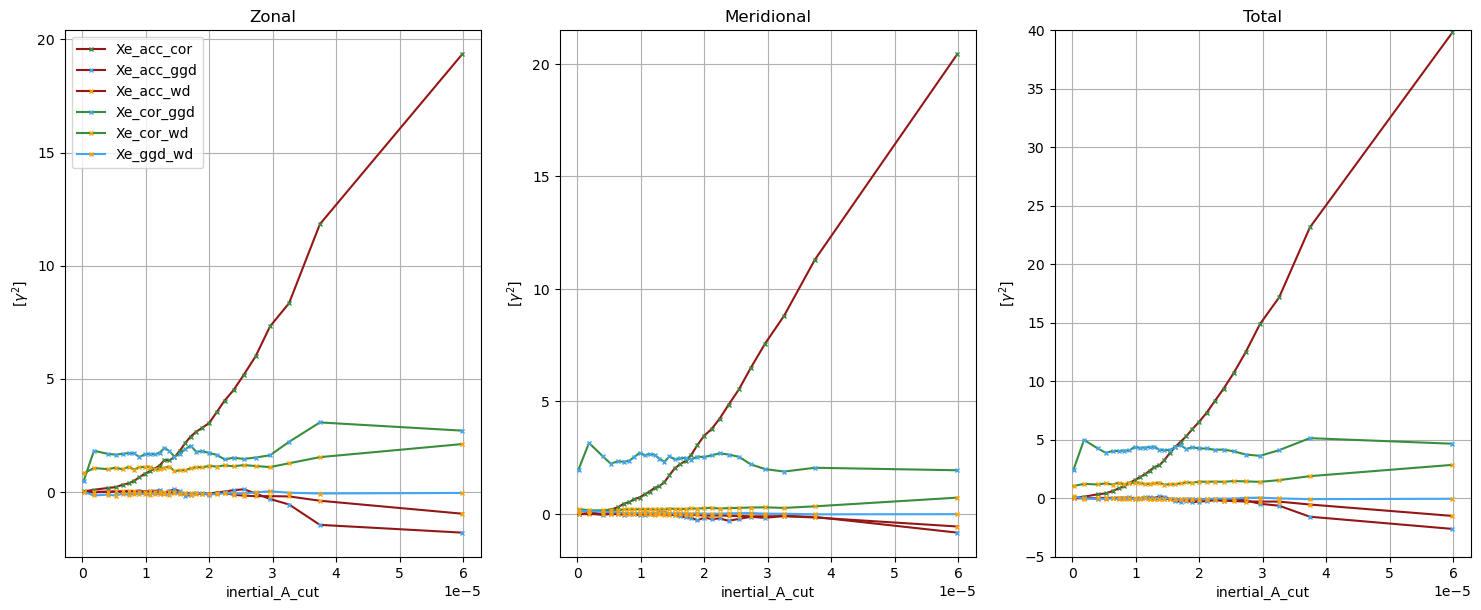

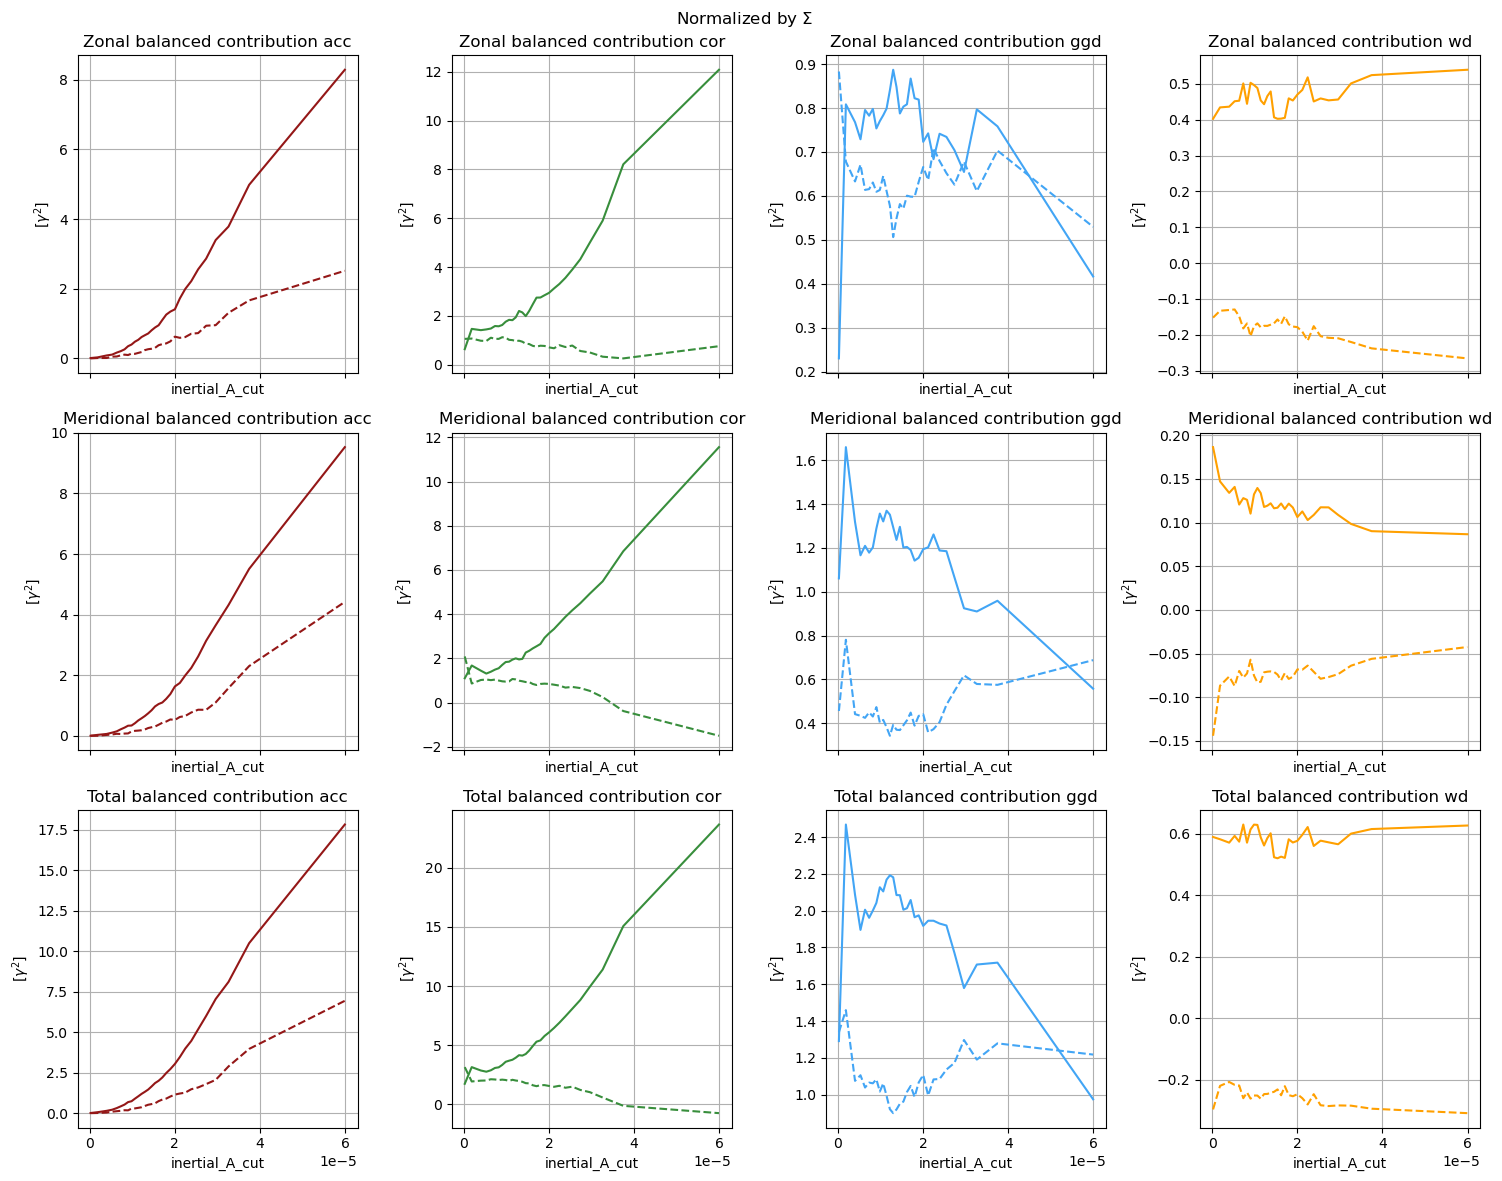

In [18]:
plot_bins_diag(dfs, dfr, "inertial_A")

______
# Surface Constrained with other velocity + constant number of coloc in bins


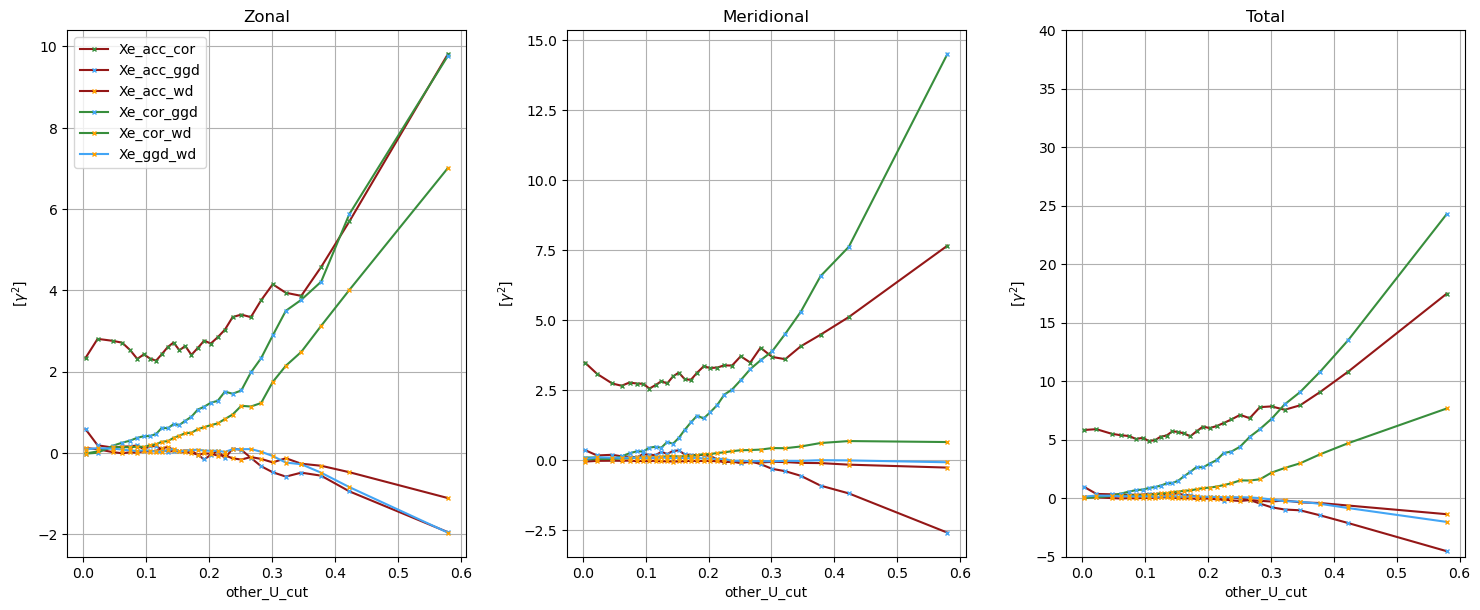

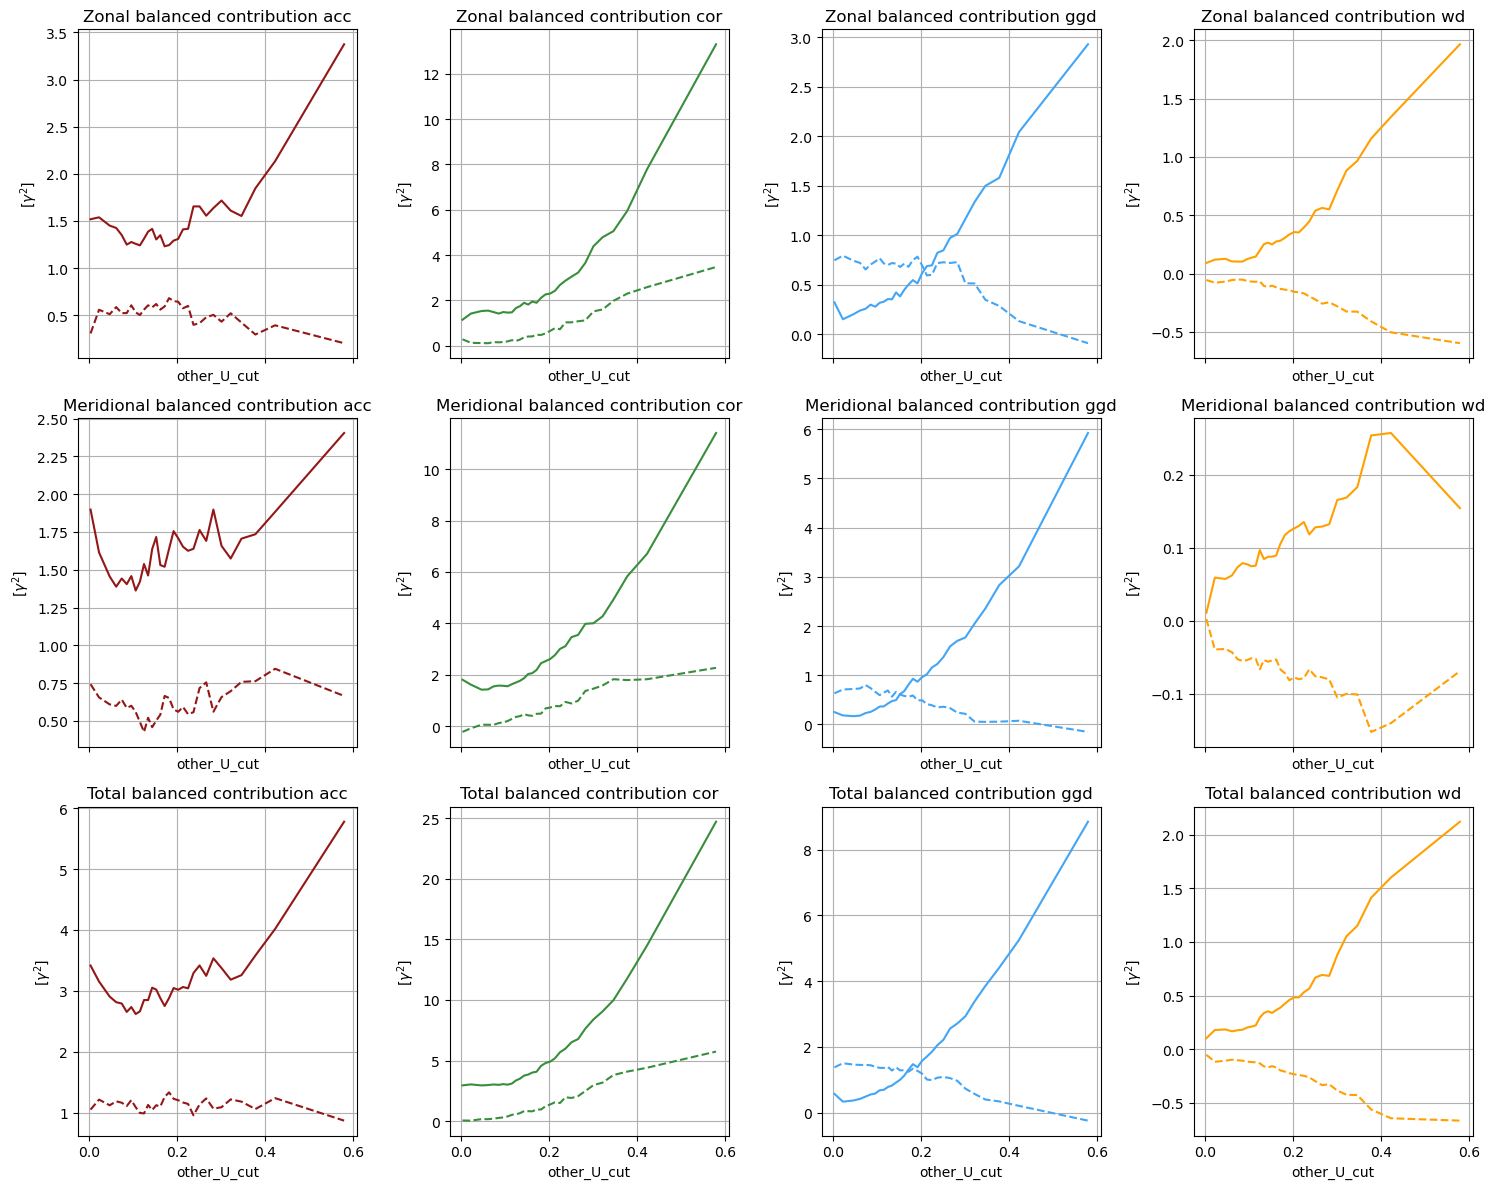

In [21]:
plot_bins_diag(dfs, dfr, "other_U")

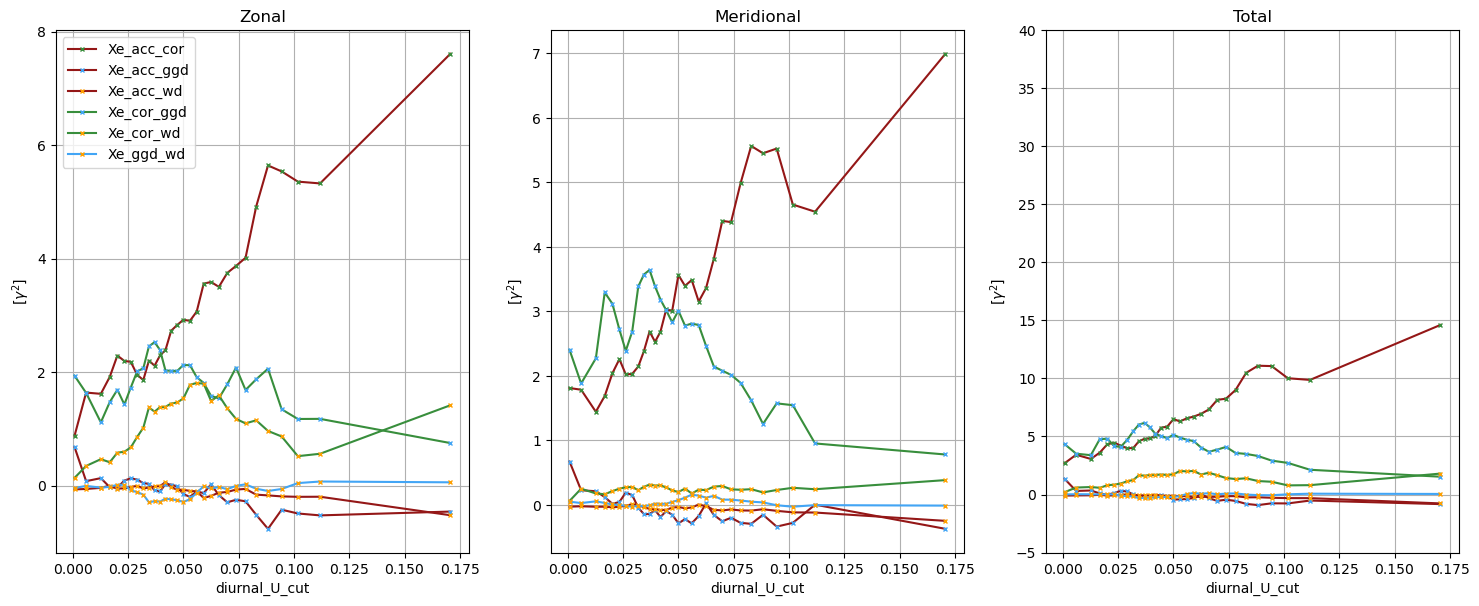

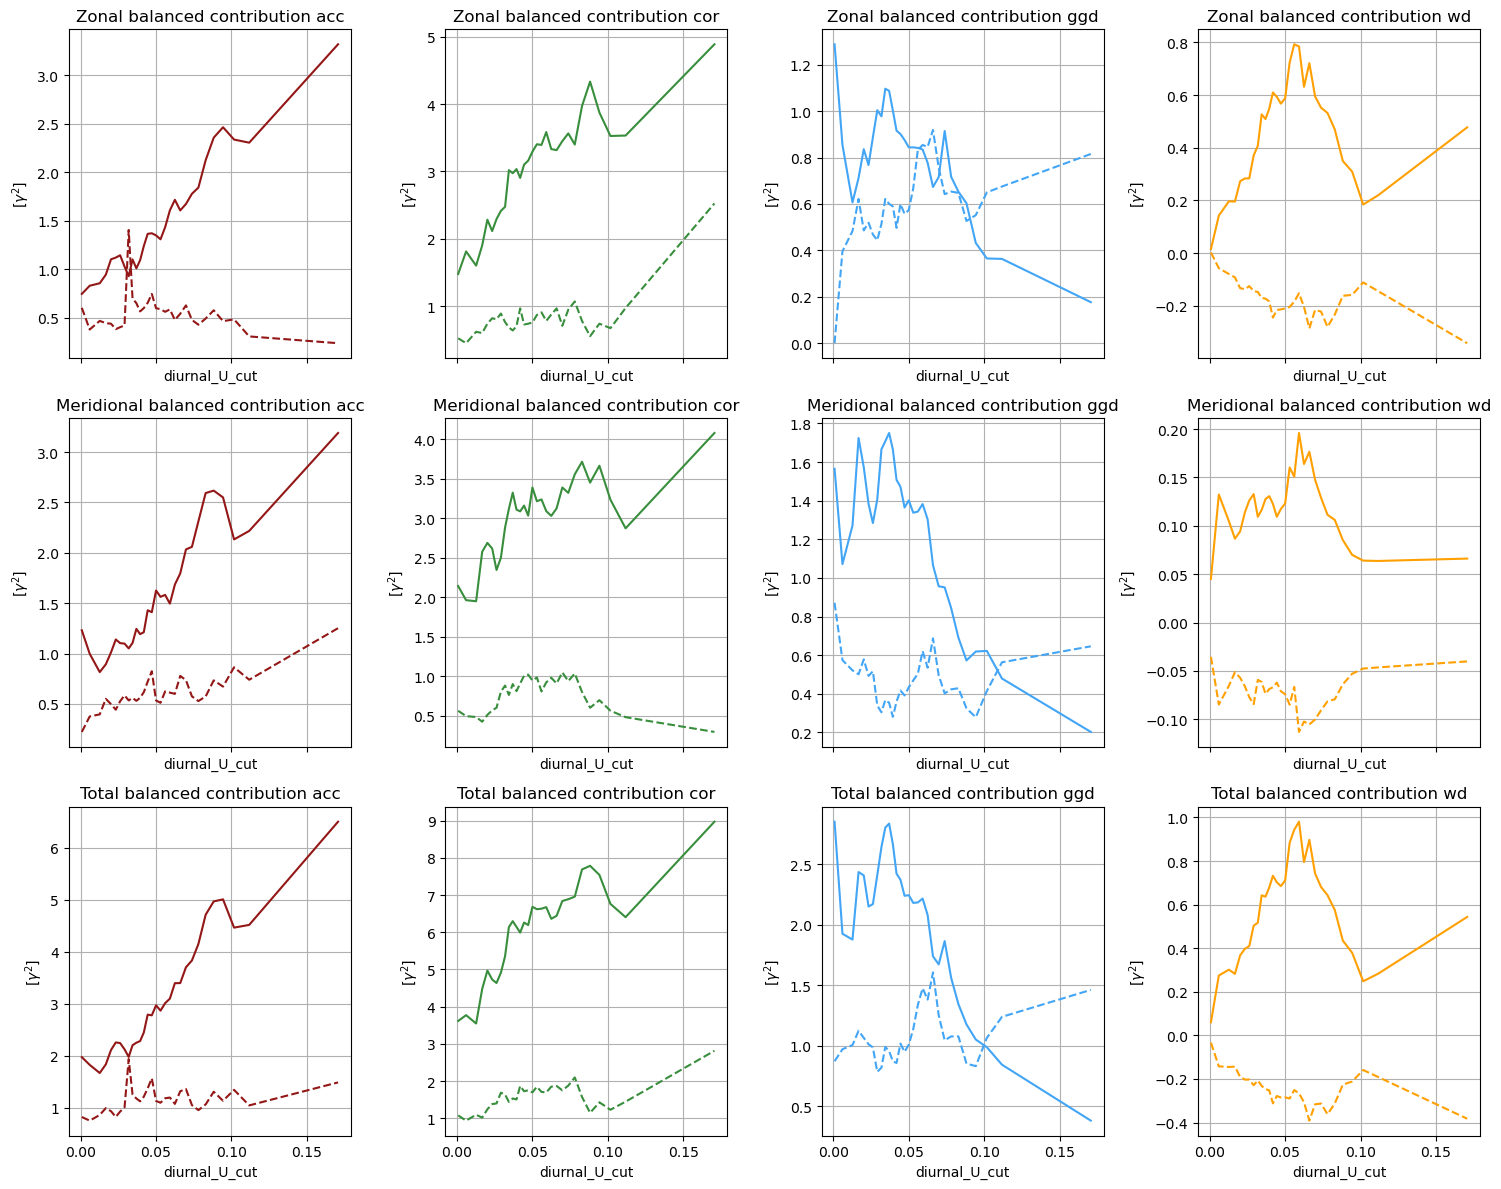

In [22]:
key_bins = "diurnal_U"
plot_bins_diag(dfs, dfr, key_bins)

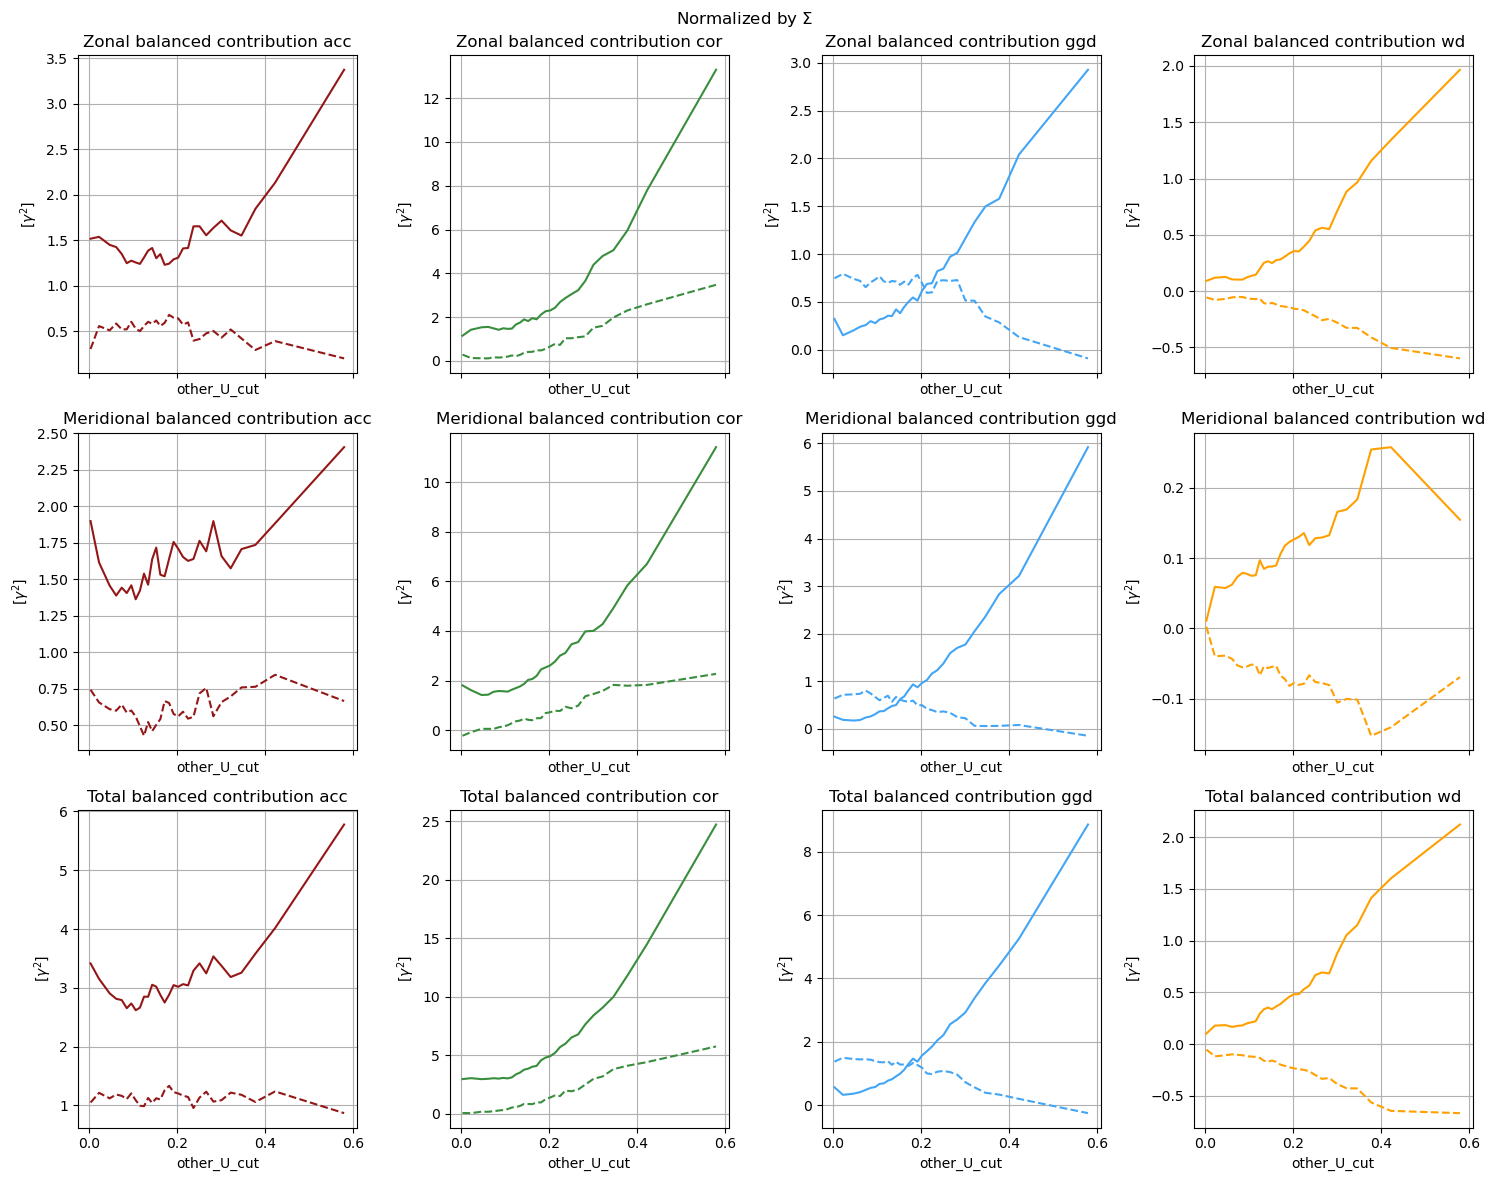

In [59]:
dfr["diurnal_U"] = np.sqrt(
    dfr.diurnal_velocity_east**2 + dfr.diurnal_velocity_north**2
)

______
# Surface Constrained with other velocity + constant number of coloc in bins


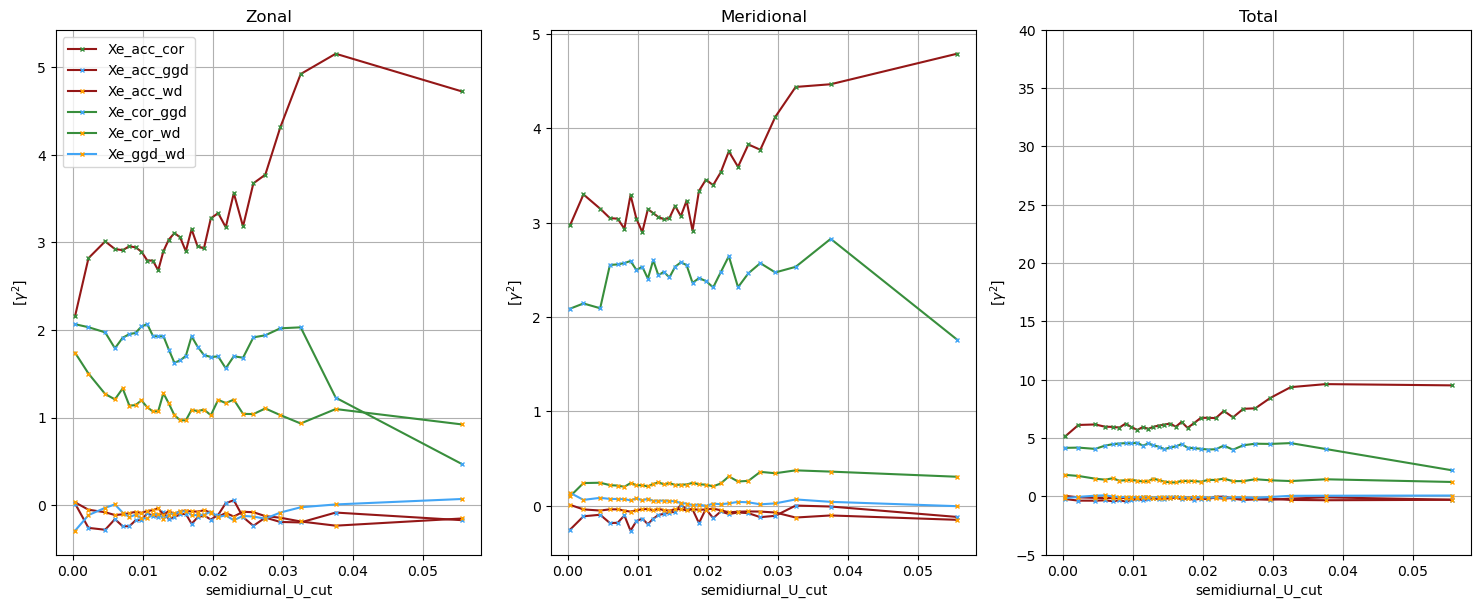

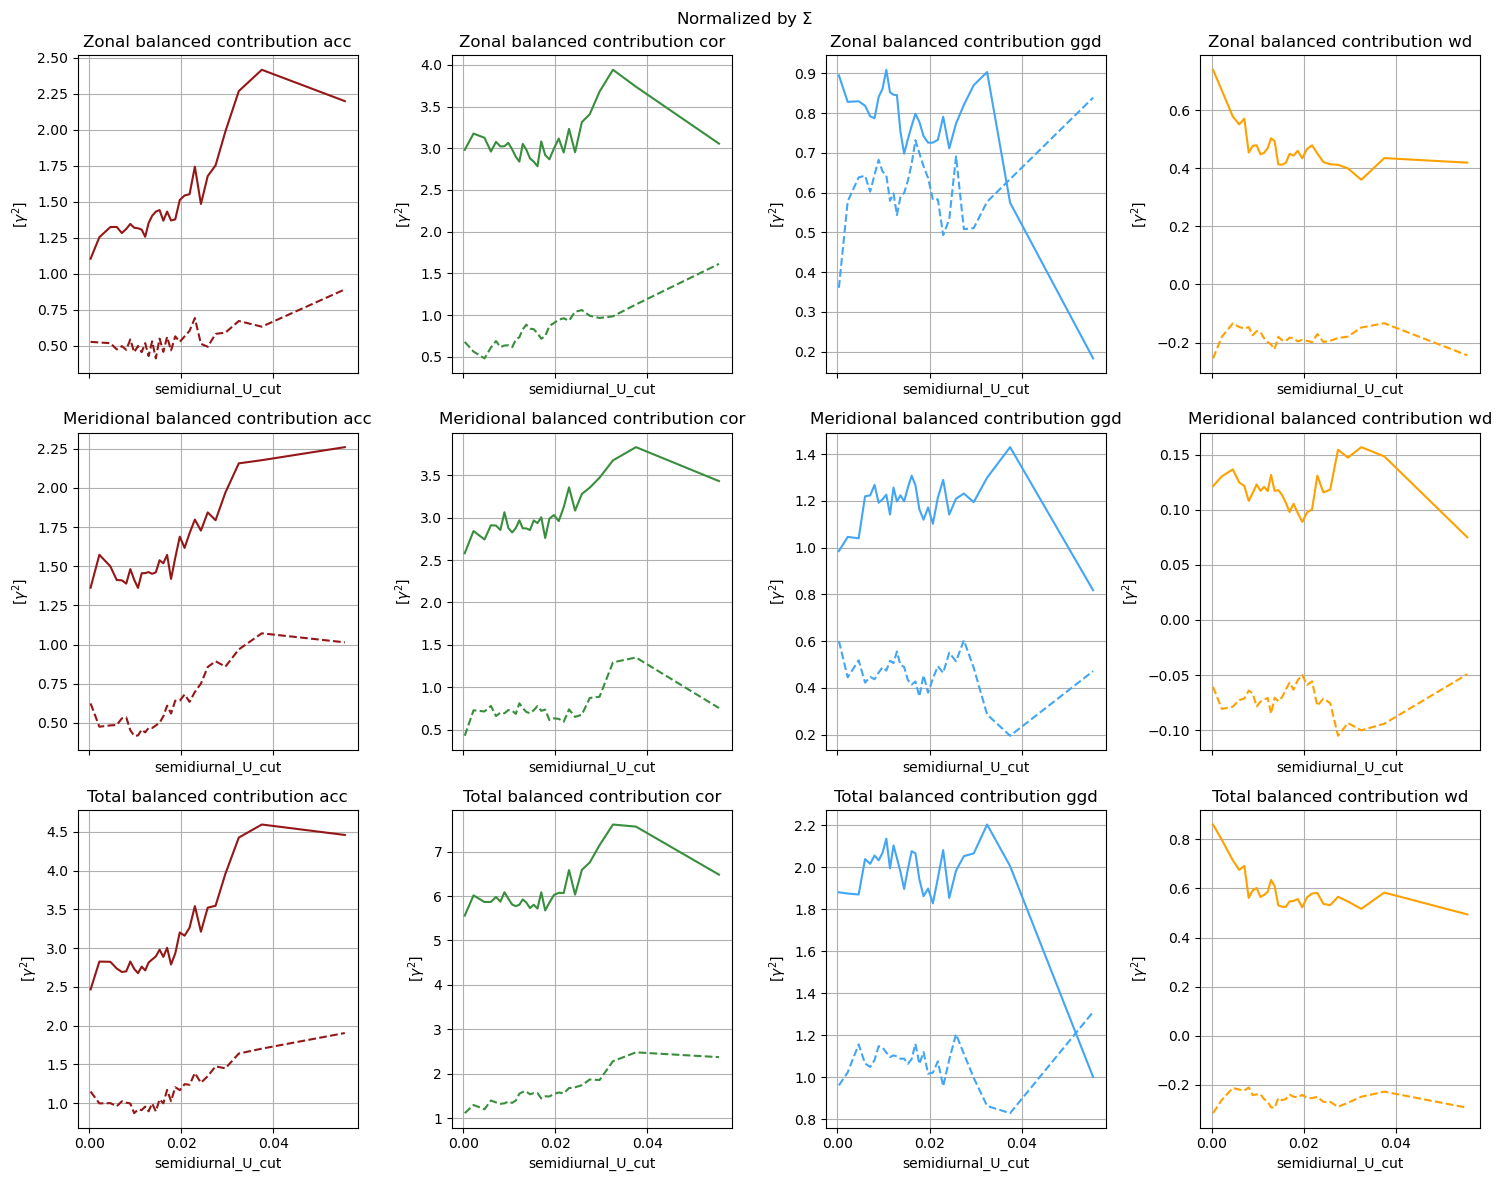

In [17]:
key_bins = "semidiurnal_U"
plot_bins_diag(dfs, dfr, key_bins)

______
# Just select high and low inertial velocity

In [61]:
dfi = dfr[dfr.inertial_U > inertialvel_09]
dfni = dfr[dfr.inertial_U < inertialvel_01]

idi = list(dfi.index)
idni = list(dfni.index)

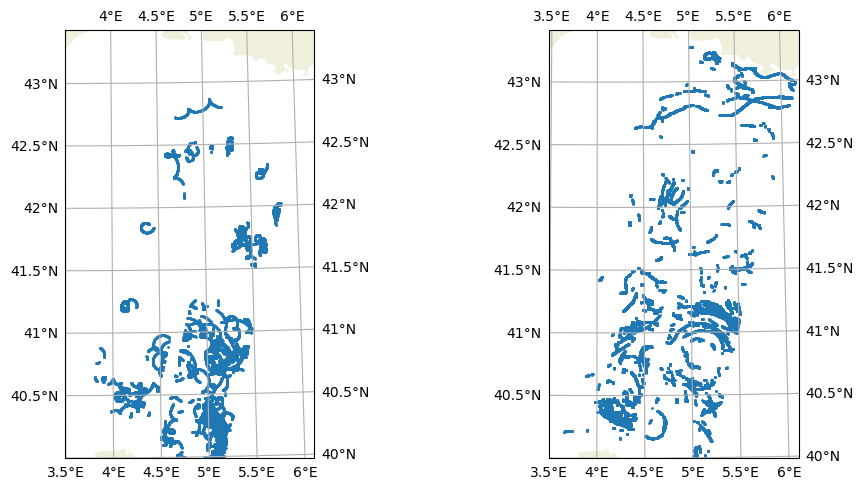

In [54]:
fig = plt.figure(figsize=(10, 5))
# bbox =[2.7, 5.1, 36.6, 40]
# bbox = [0.9, 3.7, 37.7, 41.25]
bbox = [3.5, 6.1, 40, 43.4]

ax = fig.add_subplot(
    1, 2, 1, projection=ccrs.Orthographic(dfi.longitude.mean(), dfi.latitude.mean())
)
dfi.plot.scatter(x="longitude", y="latitude", ax=ax, transform=crs, s=1)
gl = ax.gridlines(
    draw_labels=True,
)
ax.add_feature(
    cfeature.LAND,
)
ax.set_extent(bbox)

ax = fig.add_subplot(
    1, 2, 2, projection=ccrs.Orthographic(dfni.longitude.mean(), dfni.latitude.mean())
)
dfni.plot.scatter(x="longitude", y="latitude", ax=ax, transform=crs, s=1)
gl = ax.gridlines(
    draw_labels=True,
)
ax.add_feature(
    cfeature.LAND,
)
ax.set_extent(bbox)

fig.tight_layout()

In [67]:
dsni = compute_mean_square(
    DSS.sel(row_number=np.array(idni)[np.isin(idni, DSS.row_number)])
)
dsi = compute_mean_square(
    DSS.sel(row_number=np.array(idi)[np.isin(idi, DSS.row_number)])
)

In [81]:
df = (
    xr.concat([dsi / U2, dsni / U2], dim="c")
    .to_dataframe()
    .reset_index()
    .set_index("c")
)

13.279354422596178
13.93248781882114
13.202207502313469
13.463922031044874
5.381885625157352
5.547801658862287
5.747527986931363
5.83907531328499


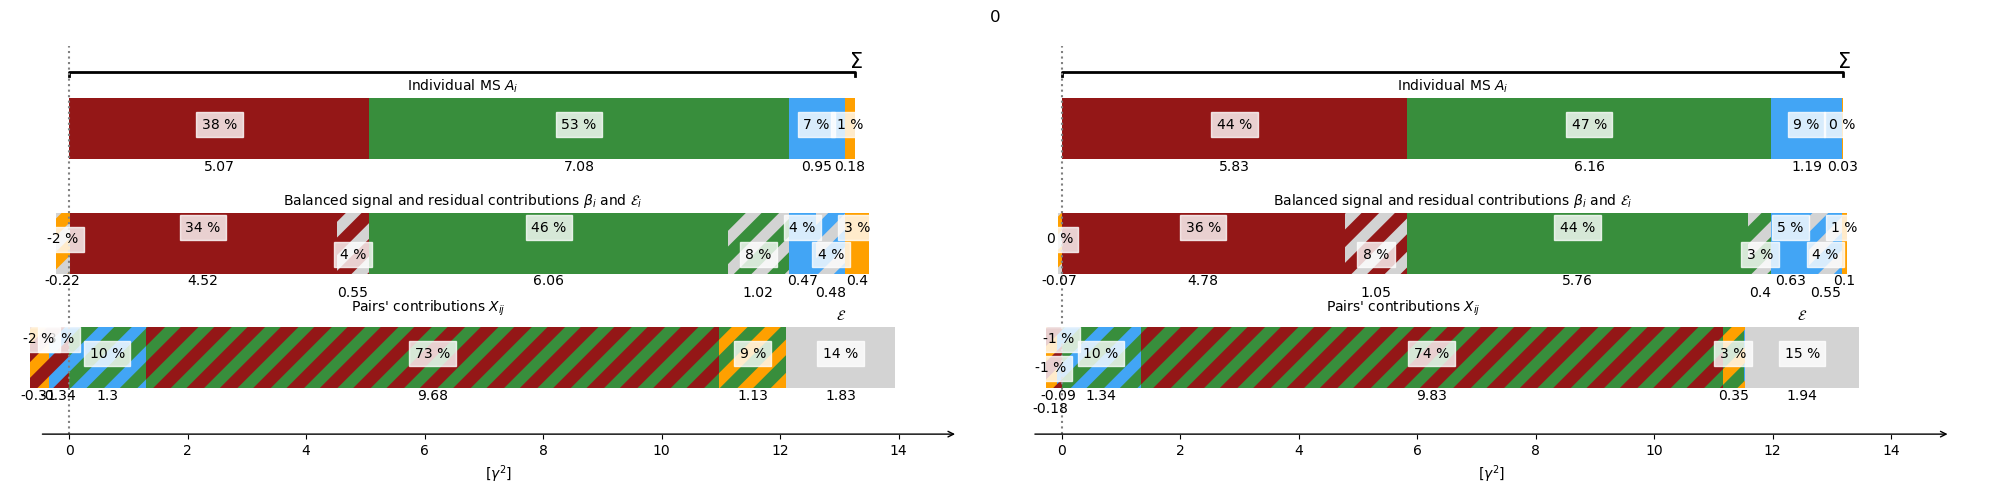

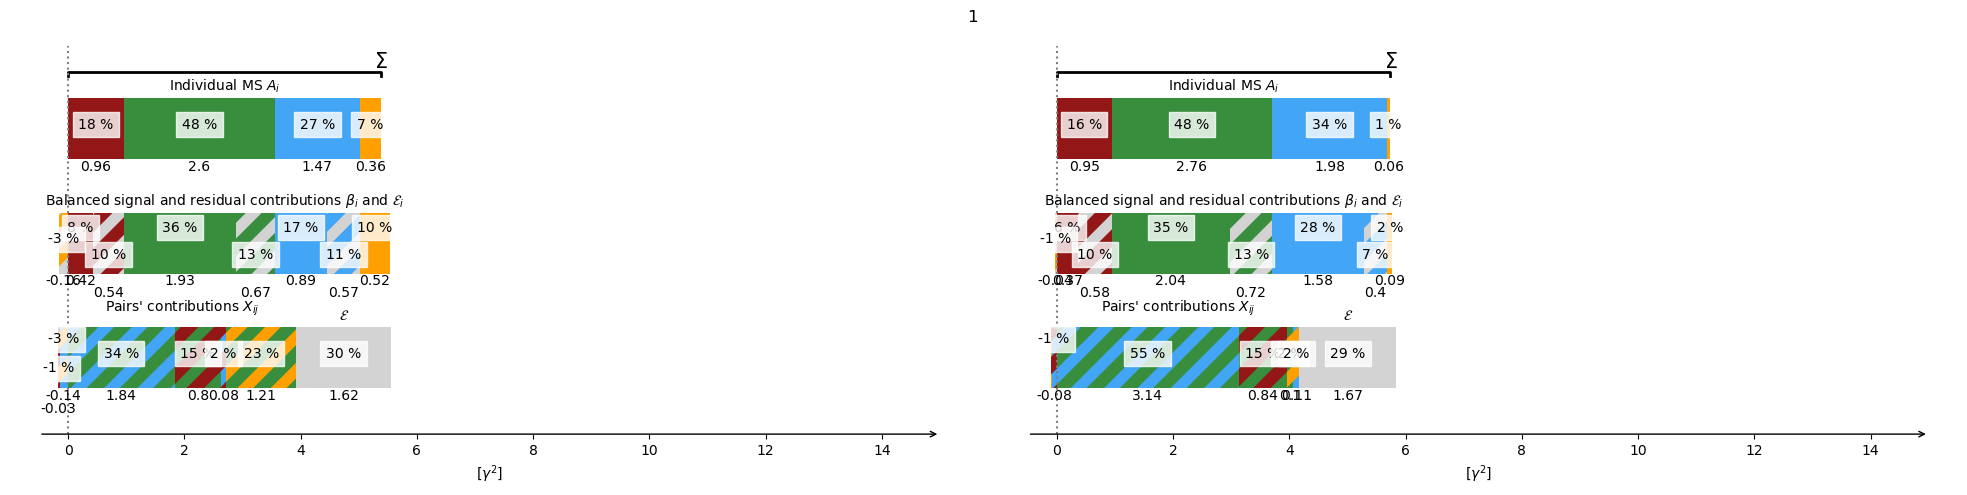

In [85]:
for c in df.index:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(20, 5), frameon=False)
    synthetic_figure(df.loc[c], axs[0], dir="e", xlim=(-1, 15))
    synthetic_figure(df.loc[c], axs[1], dir="n", xlim=(-1, 15))
    fig.suptitle(c)
    fig.tight_layout()
    # fig.savefig(os.path.join(images_dir, 'closure_figs', c + '.png'))

In [80]:
U2

9.623609999999998e-11

In [ ]:
______
# Constrained with inertial acceleration

In [ ]:
inertialacc_09 = np.sqrt(
    dfr.inertial_acceleration_east**2 + dfr.inertial_acceleration_north**2
).quantile(0.9)
inertialacc_01 = np.sqrt(
    dfr.inertial_acceleration_east**2 + dfr.inertial_acceleration_north**2
).quantile(0.9)

In [108]:
comb_list = [
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="0",
    ),
    dict(
        drifter_key="nofilter",
        alti_key="swot2kmnaive",
        wd_key="era5",
        ggd_var="etaf",
        wd_depth="15",
    ),
]

DS = (
    dataset_coloc_combs(comb_list, nearest=False)
    .dropna("row_number")
    .drop_sel(row_number=err_acc)
)
DSS = DS.where(DS.depth == 0, drop=True)
DSD = DS.where(DS.depth == 15, drop=True)
DS50 = DS.where(DS.depth == 50, drop=True)
DS100 = DS.where(DS.depth == 100, drop=True)

df = DS.isel(id_comb=0).to_dataframe()
ds = df.to_xarray()

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5


In [109]:
# Mean flow, HF flow and mean wind

df0 = pd.concat(
    [prepared_drifters("nofilter"), prepared_alti("swot2kmnaive"), prepared_wd("era5")],
    axis=1,
)
df_ = df0[df0.drifter_id == "300534060315840"]


def roll_mean_one_id(df, window):
    df_ = df.reset_index().set_index("datetime").sort_index()
    df_["meanflowe"] = abs(
        df_.velocity_east.rolling(window=pd.Timedelta(window)).mean()
    )
    df_["meanflown"] = abs(
        df_.velocity_north.rolling(window=pd.Timedelta(window)).mean()
    )
    df_["meanwinde"] = abs(df_.iews.rolling(window=pd.Timedelta(window)).mean())
    df_["meanwindn"] = abs(df_.inss.rolling(window=pd.Timedelta(window)).mean())
    df_["hfe"] = abs(df_.velocity_east.rolling(window=pd.Timedelta(window)).std())
    df_["hfn"] = abs(df_.velocity_north.rolling(window=pd.Timedelta(window)).std())
    return df_.reset_index().set_index("row_number")[
        [
            "datetime",
            "drifter_id",
            "cycle_date",
            "longitude",
            "latitude",
            "pass_number",
            "cycle_number",
            "meanwinde",
            "meanwindn",
            "meanflowe",
            "meanflown",
            "hfe",
            "hfn",
        ]
    ]


roll_mean_one_id(df_, window=pd.Timedelta("1d"))

DF = []
for id_ in df0.drifter_id.unique():
    df_ = df0[df0.drifter_id == id_]
    DF.append(roll_mean_one_id(df_, window=pd.Timedelta("1d")))
df1 = pd.concat(DF)
ds1 = df1.to_xarray().set_coords(
    [
        "datetime",
        "drifter_id",
        "cycle_date",
        "longitude",
        "latitude",
        "pass_number",
        "cycle_number",
        "longitude",
        "latitude",
    ]
)

In [110]:
# Mean over the inertial period
def roll_mean_one_id(df, window):
    df_ = df.reset_index().set_index("datetime").sort_index()
    df_["meaninertialae"] = abs(
        df_.inertial_acceleration_east.rolling(window=window).mean()
    )
    df_["meaninertialan"] = abs(
        df_.inertial_acceleration_north.rolling(window=window).mean()
    )
    df_["meaninertialae"] = abs(
        df_.inertial_acceleration_east.rolling(window=window).mean()
    )
    df_["meaninertialan"] = abs(
        df_.inertial_acceleration_north.rolling(window=window).mean()
    )
    df_["meanflowe"] = abs(
        df_.velocity_east.rolling(window=pd.Timedelta(window)).mean()
    )
    df_["meanflown"] = abs(
        df_.velocity_north.rolling(window=pd.Timedelta(window)).mean()
    )
    df_["meanwinde"] = abs(df_.iews.rolling(window=pd.Timedelta(window)).mean())
    df_["meanwindn"] = abs(df_.inss.rolling(window=pd.Timedelta(window)).mean())
    return df_.reset_index().set_index("row_number")[
        [
            "datetime",
            "drifter_id",
            "cycle_date",
            "longitude",
            "latitude",
            "pass_number",
            "cycle_number",
            "meanwinde",
            "meanwindn",
            "meanflowe",
            "meanflown",
            "meaninertiale",
            "meaninertialn",
            "hfe",
            "hfn",
        ]
    ]


dfm = roll_mean_one_id(dfr, window=pd.Timedelta((2 * np.pi / dfr.f / 3600).mean()))

Index(['datetime', 'drifter_id', 'cycle_date', 'longitude', 'latitude',
       'pass_number', 'cycle_number', 'meanwinde', 'meanwindn', 'meanflowe',
       'meanflown', 'hfe', 'hfn'],
      dtype='object')